
Dataset Loaded Successfully
  experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0        NaN                    8.0                           9      50000
1        NaN                    8.0                           6      45000
2       five                    6.0                           7      60000
3        two                   10.0                          10      65000
4      seven                    9.0                           6      70000
5      three                    7.0                          10      62000
6        ten                    NaN                           7      72000
7     eleven                    7.0                           8      80000

Cleaned Dataset
   experience  test_score(out of 10)  interview_score(out of 10)  salary($)
0           0                    8.0                           9      50000
1           0                    8.0                           6      45000
2           5                    6.0               

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


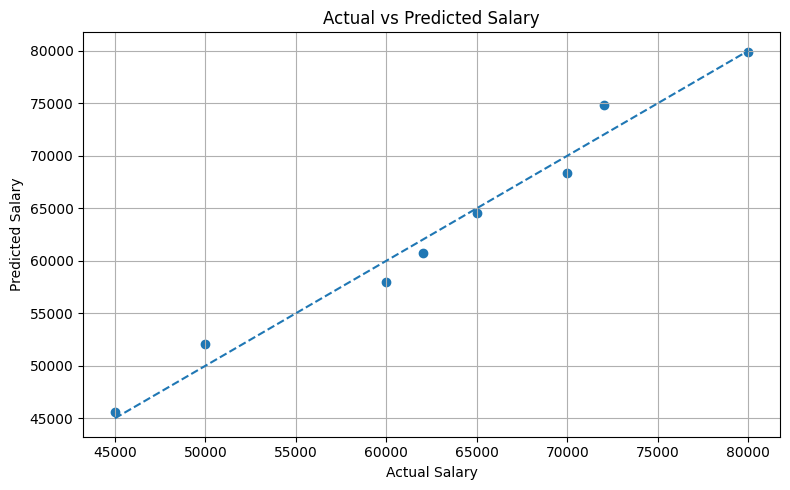

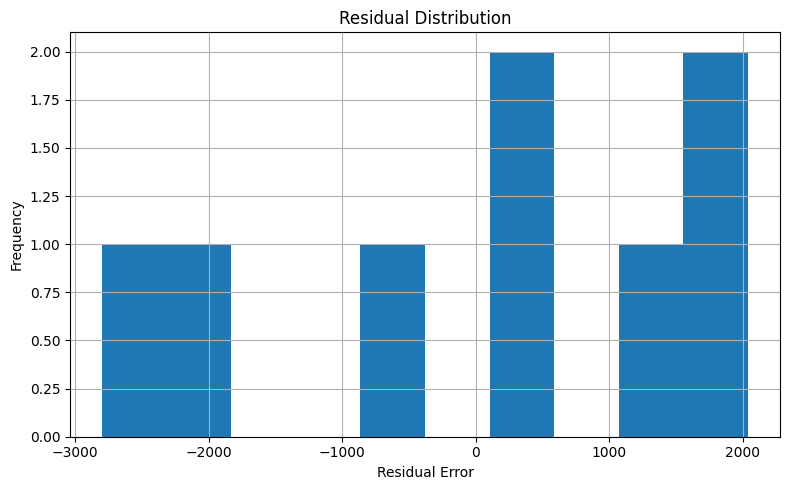


Feature Coefficients
                      Feature  Coefficient
0                  experience  2922.269015
1       test_score(out of 10)  2221.309100
2  interview_score(out of 10)  2147.482566

Model Saved Successfully


In [2]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import joblib

from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score


d = pd.read_csv("hiring.csv")

print("\nDataset Loaded Successfully")

print(d)

d.experience = d.experience.fillna("zero")

experience_mapping = {
    "zero": 0,
    "one": 1,
    "two": 2,
    "three": 3,
    "four": 4,
    "five": 5,
    "six": 6,
    "seven": 7,
    "eight": 8,
    "nine": 9,
    "ten": 10,
    "eleven": 11
}

d.experience = d.experience.map(
    experience_mapping
)

median_test_score = math.floor(
    d['test_score(out of 10)'].mean()
)

d['test_score(out of 10)'] = d[
    'test_score(out of 10)'
].fillna(median_test_score)

print("\nCleaned Dataset")

print(d)

X = d[
    [
        'experience',
        'test_score(out of 10)',
        'interview_score(out of 10)'
    ]
]

y = d['salary($)']

reg = linear_model.LinearRegression()

reg.fit(X, y)

print("\nModel Training Completed")

prediction1 = reg.predict([[2, 9, 6]])

prediction2 = reg.predict([[12, 10, 10]])

print("\nPredicted Salary for [2,9,6]:")

print(round(float(prediction1[0]), 2))

print("\nPredicted Salary for [12,10,10]:")

print(round(float(prediction2[0]), 2))

y_pred = reg.predict(X)

mse = mean_squared_error(y, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y, y_pred)

print("\nMSE:", round(mse, 4))

print("RMSE:", round(rmse, 4))

print("R2 Score:", round(r2, 4))

tolerance = 5000

correct = np.sum(
    np.abs(y - y_pred) <= tolerance
)

accuracy = correct / len(y)

print(
    "Tolerance Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

plt.figure(figsize=(8, 5))

plt.scatter(y, y_pred)

min_val = min(y.min(), y_pred.min())

max_val = max(y.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle='--'
)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.grid(True)

plt.tight_layout()

plt.savefig("salary_prediction_plot.png")

plt.show()

residuals = y - y_pred

plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=10)

plt.xlabel("Residual Error")

plt.ylabel("Frequency")

plt.title("Residual Distribution")

plt.grid(True)

plt.tight_layout()

plt.savefig("residual_distribution.png")

plt.show()

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": reg.coef_
})

print("\nFeature Coefficients")

print(coefficients)

joblib.dump(
    reg,
    "hiring_salary_model.pkl"
)

print("\nModel Saved Successfully")